# Standardized Feature Influence for Cost Prediction

## Notebook Objective

This notebook extends the baseline monthly cost regression model by comparing feature influence after numeric predictors are standardized.

The goal is not to build a new best-performing model. The goal is to make Linear Regression coefficients easier to interpret by putting numeric variables on a comparable scale.

Because the target is `monthly_cost`, this is a regression problem. The model should be evaluated with regression metrics such as MAE, RMSE, and R², not classification metrics.

## 1. Imports

In [1]:
import pandas as pd  # Used for loading and working with tabular data
import numpy as np  # Used for numerical calculations
import matplotlib.pyplot as plt 

from sklearn.model_selection import train_test_split  # Used to split data into train and test sets
from sklearn.compose import ColumnTransformer  # Used to apply different preprocessing to numeric and categorical columns
from sklearn.pipeline import Pipeline  # Used to combine preprocessing and model steps
from sklearn.preprocessing import StandardScaler, OneHotEncoder  # Used for scaling numeric features and encoding categorical features
from sklearn.linear_model import LinearRegression  # Baseline linear regression model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score  # Regression evaluation metrics



## 2. Load Processed Dataset

In [2]:
df = pd.read_csv("../data/processed/member_analysis_ready.csv")
df.head()

,member_id,age,gender,region,plan_type,sdoh_risk_score,chronic_condition_count,engagement_score,pcp_attributed_24mo,prior_awv_count,...,engagement_group,age_group,high_cost_member,chronic_burden_group,sdoh_risk_group,prior_awv_group,total_acute_visits,acute_utilization_group,pcp_status,has_acute_utilization
0,M00001,69,Male,Suburban,Medicare Advantage,40.7,2,68.9,1,1,...,Q4_High,65-79,1,Moderate,Q1_Low,1,2,Low,Attributed,1
1,M00002,32,Female,Urban,DSNP,80.0,3,30.4,0,0,...,Q1_Low,18-34,0,Moderate,Q4_High,0,2,Low,Not Attributed,1
2,M00003,89,Female,Suburban,Medicare Advantage,49.6,3,86.3,1,3,...,Q4_High,80+,0,Moderate,Q2,3,0,NaN,Attributed,0
3,M00004,78,Male,Suburban,Medicare Advantage,45.7,4,63.1,1,1,...,Q4_High,65-79,1,High,Q1_Low,1,3,Moderate,Attributed,1
4,M00005,38,Male,Suburban,Medicare Advantage,32.4,0,55.6,0,0,...,Q4_High,35-49,0,Low,Q1_Low,0,0,NaN,Not Attributed,0


## 3. Define Target and Features

In [3]:
# Define target variable and features
target = "monthly_cost"

# Drop member_id & target 

drop_cols = [
    "member_id",
    target,
    "high_cost_member",
    "awv_completed",

    # Drop full-dataset quartile / grouped features
    "engagement_group",
    "sdoh_risk_group",
    "age_group",
    "chronic_burden_group",
    "pcp_status",
    "prior_awv_group",

    # Drop redundant utilization features
    "total_acute_visits",
    "acute_utilization_group",
    "has_acute_utilization",

    # Drop duplicate prior AWV representation
    "prior_awv_count"
]

X = df.drop(columns=drop_cols, errors="ignore")  # Create predictors after removing leakage-prone columns
y = df[target]

# Then identify numeric and categorical columns:
numeric_cols = X.select_dtypes(
    include=["int64", "float64", "int32", "float32"]  # Select numeric predictors for scaling
).columns.tolist()

categorical_cols = X.select_dtypes(
    include=["object", "string", "category", "bool"]  # Select categorical/text-like predictors for encoding
).columns.tolist()

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)  # Display categorical predictors


Numeric columns: ['age', 'sdoh_risk_score', 'chronic_condition_count', 'engagement_score', 'pcp_attributed_24mo', 'prior_awv_rate', 'ed_visits', 'ip_admits']
Categorical columns: ['gender', 'region', 'plan_type']


## Feature Selection Logic

The model excludes fields that could create leakage or make interpretation unclear.

- `member_id` is excluded because it is only an identifier.
- `monthly_cost` is excluded because it is the target.
- `high_cost_member` is excluded because it is derived from `monthly_cost`.
- `awv_completed` is excluded to keep this baseline focused on risk, access, engagement, and utilization features.
- Grouped features such as `engagement_group`, `sdoh_risk_group`, and `chronic_burden_group` are excluded because the raw continuous variables are already included.
- `prior_awv_count` is excluded because `prior_awv_rate` already captures the same prior AWV behavior in normalized form.

This creates a cleaner model for coefficient interpretation.

## 4. Train Test Split

In [4]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

## 5. Build preprocessing Logic

In [5]:
# Define transformers for numeric and categorical features: numeric columns will be standardized, while categorical columns will be one-hot encoded

preprocessor = ColumnTransformer(
    transformers = [
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(drop = "first", handle_unknown = "ignore"), categorical_cols)
    
    ]
)

# Pipeline

model = Pipeline(steps = [
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

## Preprocessing Explanation

Numeric features are standardized using `StandardScaler`. This changes each numeric feature into standard-deviation units.

For numeric predictors, the coefficient should be interpreted as:

> the expected change in predicted monthly cost for a one-standard-deviation increase in that predictor, holding other included variables constant.

Categorical features are converted into dummy variables using one-hot encoding. Because `drop="first"` is used, one category from each categorical variable is omitted and becomes the reference category.

Dummy-variable coefficients should be interpreted relative to that omitted reference category.

## 6. Fit Standardized Linear Regression

In [6]:
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformer

## 7. Evaluate regression performance

In [7]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: ${mae:,.2f}")
print(f"RMSE: ${rmse:,.2f}")
print(f"R²: {r2:.3f}")

MAE: $404.20
RMSE: $654.27
R²: 0.764


## Model Performance Interpretation

The model has an MAE of about `$404`, meaning the average absolute prediction error is approximately `$404` per member per month.

The RMSE is about `$654`, which is higher than the MAE. This suggests the model makes some larger errors, likely among higher-cost members or members with unusual cost patterns.

The R² value is about `0.764`, meaning the model explains approximately 76.4% of the variation in monthly cost in the test set.

R² should not be described as model accuracy. It measures explained variance, not the percentage of predictions that are correct.

## 8. Extract transformed feature names

In [8]:
feature_names = model.named_steps["preprocessor"].get_feature_names_out()
coefficients = model.named_steps["regressor"].coef_

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients,
    "abs_coefficient": np.abs(coefficients)
})

coef_df = coef_df.sort_values("abs_coefficient", ascending = False) 
coef_df.head(20)


,feature,coefficient,abs_coefficient
2,num__chronic_condition_count,685.326198,685.326198
7,num__ip_admits,579.390145,579.390145
11,cat__plan_type_Medicaid,-545.995977,545.995977
12,cat__plan_type_Medicare Advantage,-417.503901,417.503901
6,num__ed_visits,261.574043,261.574043
10,cat__region_Urban,-105.978163,105.978163
0,num__age,63.194242,63.194242
3,num__engagement_score,-62.284947,62.284947
9,cat__region_Suburban,-48.937854,48.937854
4,num__pcp_attributed_24mo,-39.571305,39.571305


In [9]:
encoder = model.named_steps["preprocessor"].named_transformers_["cat"]

for col, categories in zip(categorical_cols, encoder.categories_):
    print(f"{col} reference category:", categories[0])

gender reference category: Female
region reference category: Rural
plan_type reference category: DSNP


## Reference Category Interpretation

Because `OneHotEncoder(drop="first")` was used, the first category for each categorical variable is omitted and becomes the reference category.

The reference categories are:

- `gender`: Female
- `region`: Rural
- `plan_type`: DSNP

This means:

- `gender_Male` is interpreted relative to Female.
- `region_Suburban` and `region_Urban` are interpreted relative to Rural.
- `plan_type_Medicaid` and `plan_type_Medicare Advantage` are interpreted relative to DSNP.

For example, a negative coefficient for `plan_type_Medicaid` means Medicaid members are predicted to have lower monthly cost than DSNP members, holding other included variables constant. It does not mean Medicaid causes lower cost.

## 9. Separate numeric vs dummy features for interpretation

In [10]:
coef_df["feature_type"] = np.where(
    coef_df["feature"].str.startswith("num__"), 
    "standardized_numeric",
    "dummy_variable"
)

coef_df.head(20)

,feature,coefficient,abs_coefficient,feature_type
2,num__chronic_condition_count,685.326198,685.326198,standardized_numeric
7,num__ip_admits,579.390145,579.390145,standardized_numeric
11,cat__plan_type_Medicaid,-545.995977,545.995977,dummy_variable
12,cat__plan_type_Medicare Advantage,-417.503901,417.503901,dummy_variable
6,num__ed_visits,261.574043,261.574043,standardized_numeric
10,cat__region_Urban,-105.978163,105.978163,dummy_variable
0,num__age,63.194242,63.194242,standardized_numeric
3,num__engagement_score,-62.284947,62.284947,standardized_numeric
9,cat__region_Suburban,-48.937854,48.937854,dummy_variable
4,num__pcp_attributed_24mo,-39.571305,39.571305,standardized_numeric


In [11]:
numeric_coef_df = coef_df[
    coef_df["feature_type"] == "standardized_numeric"
].sort_values(
    "abs_coefficient",  # Sort standardized numeric features by absolute coefficient size
    ascending=False
)

numeric_coef_df.head(10)  # Review strongest standardized numeric coefficients

,feature,coefficient,abs_coefficient,feature_type
2,num__chronic_condition_count,685.326198,685.326198,standardized_numeric
7,num__ip_admits,579.390145,579.390145,standardized_numeric
6,num__ed_visits,261.574043,261.574043,standardized_numeric
0,num__age,63.194242,63.194242,standardized_numeric
3,num__engagement_score,-62.284947,62.284947,standardized_numeric
4,num__pcp_attributed_24mo,-39.571305,39.571305,standardized_numeric
5,num__prior_awv_rate,11.236872,11.236872,standardized_numeric
1,num__sdoh_risk_score,-4.501480,4.501480,standardized_numeric


## Standardized Numeric Coefficient Interpretation

Among standardized numeric predictors, `chronic_condition_count`, `ip_admits`, and `ed_visits` have the strongest positive associations with predicted monthly cost.

Because these numeric variables were standardized, the coefficients represent the expected dollar change in predicted monthly cost for a one-standard-deviation increase in each predictor.

For example, the coefficient for `chronic_condition_count` means that a one-standard-deviation increase in chronic condition count is associated with a higher predicted monthly cost, holding other included variables constant.

These are model-based associations, not causal effects.

## Note on Standardized Binary Variables

`pcp_attributed_24mo` is a binary variable where 0 means not PCP-attributed and 1 means PCP-attributed.

In this notebook, it is included in the numeric preprocessing pipeline, so it is standardized by `StandardScaler`.

Because of that, its coefficient should not be interpreted as the raw dollar difference between PCP-attributed and non-PCP-attributed members. Instead, it represents the expected dollar change in predicted monthly cost for a one-standard-deviation increase in the standardized binary variable.

This is acceptable for standardized feature comparison, but less intuitive than leaving the binary variable unscaled.

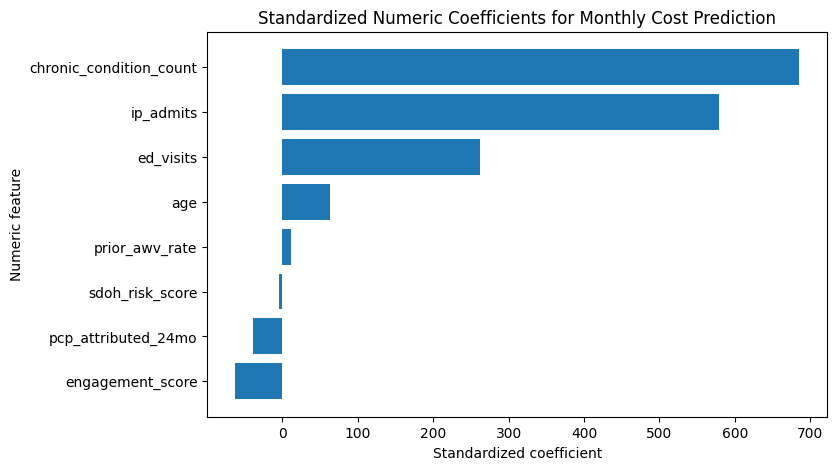

In [12]:
numeric_plot_df = numeric_coef_df.sort_values(
    by="coefficient",
    ascending=True
)

plt.figure(figsize=(8, 5))

plt.barh(
    numeric_plot_df["feature"].str.replace("num__", "", regex=False),
    numeric_plot_df["coefficient"]
)

plt.xlabel("Standardized coefficient")
plt.ylabel("Numeric feature")
plt.title("Standardized Numeric Coefficients for Monthly Cost Prediction")

plt.show()

In [13]:
dummy_coef_df = coef_df[
    coef_df["feature_type"] == "dummy_variable"
].sort_values(
    "abs_coefficient",  # Sort dummy variables by absolute coefficient size
    ascending=False
)

dummy_coef_df.head(10)  # Review strongest category-relative coefficients

,feature,coefficient,abs_coefficient,feature_type
11,cat__plan_type_Medicaid,-545.995977,545.995977,dummy_variable
12,cat__plan_type_Medicare Advantage,-417.503901,417.503901,dummy_variable
10,cat__region_Urban,-105.978163,105.978163,dummy_variable
9,cat__region_Suburban,-48.937854,48.937854,dummy_variable
8,cat__gender_Male,-13.977935,13.977935,dummy_variable


## Dummy-Variable Coefficient Interpretation

Dummy-variable coefficients are interpreted relative to their omitted reference category.

For plan type, DSNP is the reference category. Therefore, the negative coefficients for `plan_type_Medicaid` and `plan_type_Medicare Advantage` mean that these groups are predicted to have lower monthly cost than DSNP members, holding other included variables constant.

These coefficients should not be directly compared with standardized numeric coefficients because they are measured differently.

In [14]:
numeric_coef_df.sort_values(
    "coefficient",  # Sort by coefficient direction
    ascending=False
).head(10)  # Numeric features associated with higher predicted monthly cost

,feature,coefficient,abs_coefficient,feature_type
2,num__chronic_condition_count,685.326198,685.326198,standardized_numeric
7,num__ip_admits,579.390145,579.390145,standardized_numeric
6,num__ed_visits,261.574043,261.574043,standardized_numeric
0,num__age,63.194242,63.194242,standardized_numeric
5,num__prior_awv_rate,11.236872,11.236872,standardized_numeric
1,num__sdoh_risk_score,-4.501480,4.501480,standardized_numeric
4,num__pcp_attributed_24mo,-39.571305,39.571305,standardized_numeric
3,num__engagement_score,-62.284947,62.284947,standardized_numeric


In [15]:
numeric_coef_df.sort_values(
    "coefficient",  # Sort by coefficient direction
    ascending=True
).head(10)  # Numeric features associated with lower predicted monthly cost

,feature,coefficient,abs_coefficient,feature_type
3,num__engagement_score,-62.284947,62.284947,standardized_numeric
4,num__pcp_attributed_24mo,-39.571305,39.571305,standardized_numeric
1,num__sdoh_risk_score,-4.501480,4.501480,standardized_numeric
5,num__prior_awv_rate,11.236872,11.236872,standardized_numeric
0,num__age,63.194242,63.194242,standardized_numeric
6,num__ed_visits,261.574043,261.574043,standardized_numeric
7,num__ip_admits,579.390145,579.390145,standardized_numeric
2,num__chronic_condition_count,685.326198,685.326198,standardized_numeric


## Findings

The purpose of this notebook was to compare feature influence after standardizing numeric predictors in a linear regression model.

The target variable was `monthly_cost`.

The predictor set excluded `member_id`, `high_cost_member`, and `awv_completed`. `member_id` was excluded because it is only an identifier. `high_cost_member` was excluded because it is derived from `monthly_cost` and would create target leakage. `awv_completed` was excluded to keep the cost prediction model focused on member characteristics, risk, access, and utilization.

Numeric predictors were standardized using `StandardScaler`, while categorical predictors were one-hot encoded.

For standardized numeric predictors, coefficients can be compared more meaningfully because they represent the expected change in predicted monthly cost for a one-standard-deviation increase in the predictor, holding other included variables constant.

Dummy-variable coefficients still require category-relative interpretation. They represent differences compared with the omitted reference category, holding other included variables constant.

Standardization improves coefficient comparability across numeric predictors, but it does not solve multicollinearity. These coefficients remain conditional model-based associations, not causal effects.

The strongest standardized numeric cost-associated predictors were chronic condition count, inpatient admissions, and ED visits.

Plan type had large dummy-variable coefficients, but these are interpreted relative to DSNP as the reference category and should not be directly compared with standardized numeric coefficients.

`pcp_attributed_24mo` is binary but was standardized in this notebook, so its coefficient represents a one-standard-deviation increase in the standardized binary variable rather than a raw 0-to-1 change.

Because this is synthetic data, the observed relationships reflect the assumptions built into the data-generation process and should not be interpreted as real-world causal evidence.
